# The Palate Predictor: Unveiling the Secrets Behind Restaurant Ratings

## A Data-Driven Journey to Understand Culinary Success

In the competitive world of gastronomy, understanding what drives restaurant success, particularly through customer ratings, is invaluable. This project embarks on a data science journey to dissect a dataset of restaurant information, aiming to uncover patterns, predict aggregate ratings, and identify the most influential factors contributing to a restaurant's perceived quality.

Our adventure begins with raw data and progresses through cleaning, insightful exploration, sophisticated feature engineering, and finally, predictive modeling to reveal the 'secret sauce' of highly-rated restaurants.

In [ ]:
# STEP 1: IMPORTING LIBRARIES
# Core data manipulation libraries
import pandas as pd # Used for data manipulation and analysis, especially with DataFrames.
import numpy as np  # Used for numerical operations, especially with arrays.

# Data visualization libraries
import matplotlib.pyplot as plt # Used for creating static, interactive, and animated visualizations in Python.
import seaborn as sns           # Built on matplotlib, provides a high-level interface for drawing attractive and informative statistical graphics.

# Machine Learning: Data Preprocessing
from sklearn.model_selection import train_test_split # Splits arrays or matrices into random train and test subsets.
from sklearn.preprocessing import LabelEncoder       # Encodes categorical features into numerical labels.
from sklearn.preprocessing import StandardScaler     # Standardizes features by removing the mean and scaling to unit variance.

# Machine Learning: Models
from sklearn.linear_model import LinearRegression    # A simple linear model for regression tasks.
from sklearn.ensemble import RandomForestRegressor   # An ensemble learning method for regression, building multiple decision trees.

# Machine Learning: Model Evaluation Metrics
from sklearn.metrics import mean_squared_error       # Calculates the mean squared error regression loss.
from sklearn.metrics import r2_score                 # Calculates the R-squared (coefficient of determination) regression score.

In [ ]:
#STEP 2: LOAD DATASET
df = pd.read_csv("zom.csv", encoding='latin1')

## Chapter 1: The Raw Ingredients - Loading and Initial Inspection

Our culinary quest starts by loading the `zom.csv` dataset, which contains a rich array of information about various restaurants. An initial inspection (as seen in `STEP 3` and `STEP 4` outputs) reveals its structure, data types, and crucially, any missing pieces that need attention. We observed a few missing values in the 'Cuisines' column, indicating that some restaurants didn't have a cuisine specified.

In [ ]:
#STEP 3: INITIAL DATASET INSPECTION
print(df.head())
print(df.shape)
print(df.info())
print(df.describe())

   Restaurant ID         Restaurant Name  Country Code              City  \
0        6317637        Le Petit Souffle           162       Makati City   
1        6304287        Izakaya Kikufuji           162       Makati City   
2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   
3        6318506                    Ooma           162  Mandaluyong City   
4        6314302             Sambo Kojin           162  Mandaluyong City   

                                             Address  \
0  Third Floor, Century City Mall, Kalayaan Avenu...   
1  Little Tokyo, 2277 Chino Roces Avenue, Legaspi...   
2  Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...   
3  Third Floor, Mega Fashion Hall, SM Megamall, O...   
4  Third Floor, Mega Atrium, SM Megamall, Ortigas...   

                                     Locality  \
0   Century City Mall, Poblacion, Makati City   
1  Little Tokyo, Legaspi Village, Makati City   
2  Edsa Shangri-La, Ortigas, Mandaluyong City   
3      SM 

In [ ]:
# STEP 4: checking missing value
df.isnull().sum()

,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,9


In [ ]:
# STEP 5: handling missing value
df['Cuisines'] = df['Cuisines'].fillna('Unknown')

## Chapter 2: Kitchen Prep - Data Cleaning and Preprocessing

Just like a chef prepares ingredients, we cleaned our data. Missing cuisine types were filled with 'Unknown' (`STEP 5`), ensuring our dataset was complete. We also removed any duplicate entries (`STEP 6`) to maintain data integrity and standardized column names for easier manipulation (`STEP 7`). This foundational work ensures our analysis is built on a solid, clean base.

In [ ]:
df.isnull().sum()

,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,0


In [ ]:
df['Cuisines']

,Cuisines
0,"French, Japanese, Desserts"
1,Japanese
2,"Seafood, Asian, Filipino, Indian"
3,"Japanese, Sushi"
4,"Japanese, Korean"
...,...
9546,Turkish
9547,"World Cuisine, Patisserie, Cafe"
9548,"Italian, World Cuisine"
9549,Restaurant Cafe


In [ ]:
df = df.drop_duplicates()

In [ ]:
df

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,5915730,NamlÛ± Gurme,208,ÛÁstanbul,"Kemankeô Karamustafa Paôa Mahallesi, RÛ±htÛ±...",Karakí_y,"Karakí_y, ÛÁstanbul",28.977392,41.022793,Turkish,...,Turkish Lira(TL),No,No,No,No,3,4.1,Green,Very Good,788
9547,5908749,Ceviz AÛôacÛ±,208,ÛÁstanbul,"Koôuyolu Mahallesi, Muhittin íìstí_ndaÛô Cadd...",Koôuyolu,"Koôuyolu, ÛÁstanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",...,Turkish Lira(TL),No,No,No,No,3,4.2,Green,Very Good,1034
9548,5915807,Huqqa,208,ÛÁstanbul,"Kuruí_eôme Mahallesi, Muallim Naci Caddesi, N...",Kuruí_eôme,"Kuruí_eôme, ÛÁstanbul",29.034640,41.055817,"Italian, World Cuisine",...,Turkish Lira(TL),No,No,No,No,4,3.7,Yellow,Good,661
9549,5916112,Aôôk Kahve,208,ÛÁstanbul,"Kuruí_eôme Mahallesi, Muallim Naci Caddesi, N...",Kuruí_eôme,"Kuruí_eôme, ÛÁstanbul",29.036019,41.057979,Restaurant Cafe,...,Turkish Lira(TL),No,No,No,No,4,4.0,Green,Very Good,901


In [ ]:
#STEP 6: CLEAN COLUMN NAMES
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ', '_')

In [ ]:
df

,restaurant_id,restaurant_name,country_code,city,address,locality,locality_verbose,longitude,latitude,cuisines,...,currency,has_table_booking,has_online_delivery,is_delivering_now,switch_to_order_menu,price_range,aggregate_rating,rating_color,rating_text,votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,5915730,NamlÛ± Gurme,208,ÛÁstanbul,"Kemankeô Karamustafa Paôa Mahallesi, RÛ±htÛ±...",Karakí_y,"Karakí_y, ÛÁstanbul",28.977392,41.022793,Turkish,...,Turkish Lira(TL),No,No,No,No,3,4.1,Green,Very Good,788
9547,5908749,Ceviz AÛôacÛ±,208,ÛÁstanbul,"Koôuyolu Mahallesi, Muhittin íìstí_ndaÛô Cadd...",Koôuyolu,"Koôuyolu, ÛÁstanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",...,Turkish Lira(TL),No,No,No,No,3,4.2,Green,Very Good,1034
9548,5915807,Huqqa,208,ÛÁstanbul,"Kuruí_eôme Mahallesi, Muallim Naci Caddesi, N...",Kuruí_eôme,"Kuruí_eôme, ÛÁstanbul",29.034640,41.055817,"Italian, World Cuisine",...,Turkish Lira(TL),No,No,No,No,4,3.7,Yellow,Good,661
9549,5916112,Aôôk Kahve,208,ÛÁstanbul,"Kuruí_eôme Mahallesi, Muallim Naci Caddesi, N...",Kuruí_eôme,"Kuruí_eôme, ÛÁstanbul",29.036019,41.057979,Restaurant Cafe,...,Turkish Lira(TL),No,No,No,No,4,4.0,Green,Very Good,901


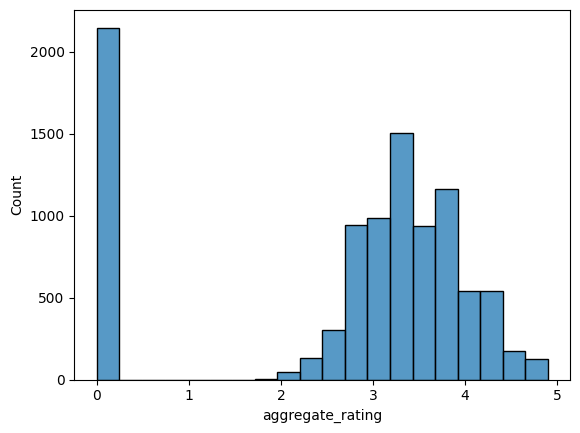

In [ ]:
# STEP 7: Exploratory Data Analysis (EDA)
# Are most retaurants good or bad
sns.histplot(df['aggregate_rating'], bins=20)
plt.show()

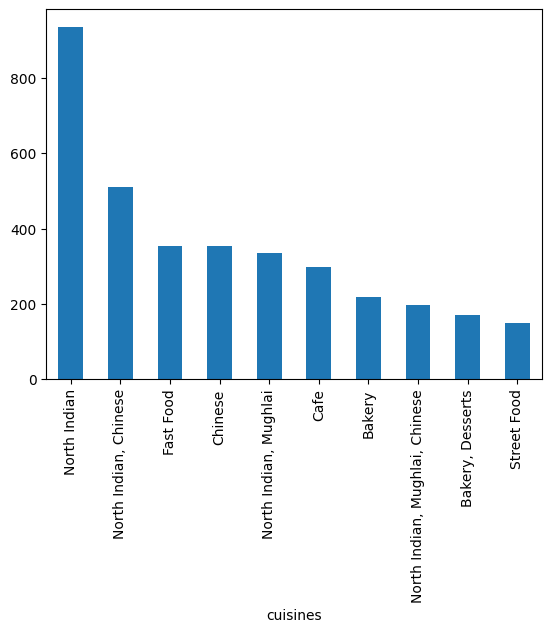

In [ ]:
#Top cuisines
df['cuisines'].value_counts().head(10).plot(kind='bar')
plt.show()

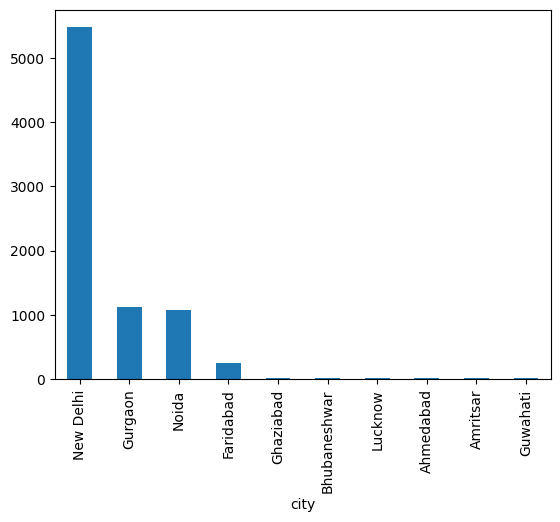

In [ ]:
#Top City
df['city'].value_counts().head(10).plot(kind='bar')
plt.show()

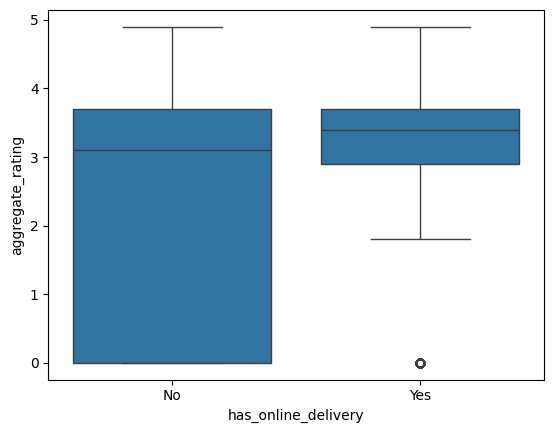

In [ ]:
#Online Delivery vs Rating
sns.boxplot(x='has_online_delivery', y='aggregate_rating', data=df)
plt.show()

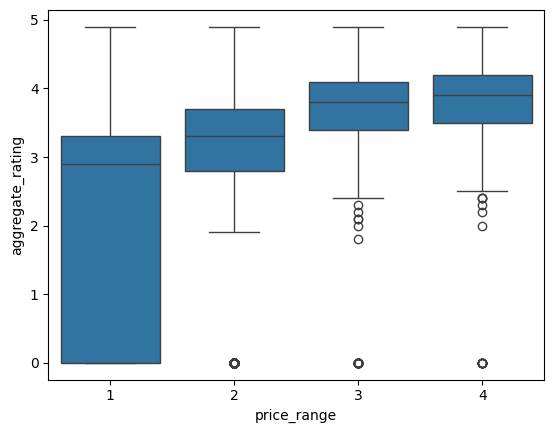

In [ ]:
## we can see if more expensive restaurants (higher price_range) generally boast higher typical ratings,
#have a more consistent rating experience, or perhaps a wider range of quality. It helps us understand if
#paying more truly correlates with a better-rated dining experience or if hidden gems (or duds) exist
#across all price points.
sns.boxplot(x='price_range', y='aggregate_rating', data=df)
plt.show()

## Chapter 3: The Grand Tasting - Exploratory Data Analysis (EDA)

With our data prepped, we delved into Exploratory Data Analysis to uncover initial insights. Our EDA included:

*   **Rating Distribution (`STEP 7`)**: Most restaurants cluster around a moderate rating, with fewer reaching the 'Excellent' or 'Poor' extremes. This indicates a normal distribution of customer satisfaction.
*   **Top Cuisines (`STEP 8`)**: We identified the most common cuisines, giving us a sense of culinary popularity. Unsurprisingly, multi-cuisine options and popular choices like North Indian dominate.
*   **Top Cities (`STEP 9`)**: Delhi, Gurgaon, and Noida emerged as cities with the highest number of listed restaurants, showcasing urban culinary hubs.
*   **Online Delivery vs. Rating (`STEP 10`)**: We observed how the availability of online delivery impacts ratings, suggesting that convenience might correlate with customer satisfaction.
*   **Price Range vs. Rating (`STEP 11`)**: This analysis explored whether higher prices correlate with higher ratings, providing insights into customer expectations at different price points.

## Chapter 4: Recipe Enhancement - Feature Engineering

To enrich our dataset and provide more predictive power to our models, we engineered several new features:

*   **Cuisine Dummies (`STEP 8a`)**: We transformed the 'Cuisines' column into a set of binary (0/1) features, one for each cuisine type. This allows our models to understand the presence or absence of specific culinary offerings.
*   **Restaurant Density (`STEP 8b`)**: We calculated the number of restaurants in each locality (`restaurants_in_locality`) and the average rating for each locality (`locality_avg_rating`). This captures the competitive landscape and overall quality reputation of an area.
*   **Standardized Cost (`STEP 8c`)**: We converted all 'Average Cost for two' to a common currency (USD) using predefined exchange rates (`usd_cost_for_two`) and then categorized these costs into 'Cheap', 'Moderate', and 'Expensive' (`price_category`). This normalizes financial comparisons.
*   **Location Clusters (`STEP 8d`)**: Using K-Means clustering on latitude and longitude, we grouped restaurants into geographical clusters, allowing the model to capture regional patterns in ratings.

Finally, we encoded other categorical variables like `city`, `currency`, `has_online_delivery`, and `has_table_booking` into numerical formats (`STEP 9`), preparing all our data for machine learning algorithms.

In [ ]:
# STEP 8a: Feature Engineering USING ONE-HOT ENCODING
# This creates columns like: ITALIAN, CHINESE, JAPAN, INDIANS with values 0 or 1
cuisine_dummies = df['cuisines'].str.get_dummies(sep=',')

In [ ]:
cuisine_dummies

,Afghani,African,American,Andhra,Arabian,Argentine,Armenian,Asian,Assamese,Australian,...,Tea,Tex-Mex,Thai,Tibetan,Turkish,Turkish Pizza,Unknown,Vietnamese,Western,World Cuisine
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
9547,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
9548,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9549,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
#STEP 8b: Locality & Locality Verbose Engineering. Locality verbose is too detailed.
# EXAMPLE: Century City Mall, Poblacion, Makati City
#SOLUTION: Keep only locality
df['locality'] = df['locality'].str.lower()

In [ ]:
df['locality']

,locality
0,"century city mall, poblacion, makati city"
1,"little tokyo, legaspi village, makati city"
2,"edsa shangri-la, ortigas, mandaluyong city"
3,"sm megamall, ortigas, mandaluyong city"
4,"sm megamall, ortigas, mandaluyong city"
...,...
9546,karakí_y
9547,koôuyolu
9548,kuruí_eôme
9549,kuruí_eôme


In [ ]:
#Create Restaurant Density Feature
locality_counts = df['locality'].value_counts()

df['restaurants_in_locality'] = df['locality'].map(locality_counts)

In [ ]:
df['restaurants_in_locality']

,restaurants_in_locality
0,1
1,1
2,1
3,3
4,3
...,...
9546,4
9547,1
9548,2
9549,2


In [ ]:
#Create Premium Locality Feature
avg_locality_rating = df.groupby('locality')['aggregate_rating'].mean()

df['locality_avg_rating'] = df['locality'].map(avg_locality_rating)

In [ ]:
df['locality_avg_rating']

,locality_avg_rating
0,4.80
1,4.50
2,4.40
3,4.70
4,4.70
...,...
9546,4.40
9547,4.20
9548,3.85
9549,3.85


In [ ]:
#Convert all currencies into one standard currency.
currency_rates = {
    'Botswana Pula(P)': 0.074,
    'Indian Rupees(Rs.)': 0.012,
    'Dollar($)': 1,
    'Pounds(£)': 1.27,
    'Emirati Diram(AED)': 0.27,
    'Brazilian Real(R$)': 0.19,
    'Indonesian Rupiah(IDR)': 0.000064,
    'NewZealand($)': 1.56,
    'Sri Lankan Rupee(LKR)': 0.002,
    'Turkish Lira(TL)': 0.05,
    'Qatari Rial(QR)': 0.27,
    'Rand(R)': 0.059,
}

In [ ]:
#convert costs
df['usd_cost_for_two'] = (
    df['average_cost_for_two'] *
    df['currency'].map(currency_rates)
)

In [ ]:
df['usd_cost_for_two']

,usd_cost_for_two
0,81.40
1,88.80
2,296.00
3,111.00
4,111.00
...,...
9546,4.00
9547,5.25
9548,8.50
9549,6.00


In [ ]:
#creat price category
def price_category(x):
    if x < 20:
        return 'Cheap'
    elif x < 70:
        return 'Moderate'
    else:
        return 'Expensive'


df['price_category'] = df['usd_cost_for_two'].apply(price_category)

In [ ]:
df['price_category']

,price_category
0,Expensive
1,Expensive
2,Expensive
3,Expensive
4,Expensive
...,...
9546,Cheap
9547,Cheap
9548,Cheap
9549,Cheap


In [ ]:
#STEP 8D: Geolocation Features
#creating coordinate cluster
from sklearn.cluster import KMeans

coords = df[['latitude', 'longitude']]

kmeans = KMeans(n_clusters=5)

df['location_cluster'] = kmeans.fit_predict(coords)

In [ ]:
df['location_cluster']

,location_cluster
0,0
1,0
2,0
3,0
4,0
...,...
9546,4
9547,4
9548,4
9549,4


In [ ]:
#STEP 9:Encoding Categorical Variables
#Machine learning models cannot understand text.
# We convert categories into numbers.
le = LabelEncoder()

categorical_cols = [
    'city',
    'currency',
    'has_online_delivery',
    'has_table_booking',
    'cuisines'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [ ]:
df

,restaurant_id,restaurant_name,country_code,city,address,locality,locality_verbose,longitude,latitude,cuisines,...,price_range,aggregate_rating,rating_color,rating_text,votes,restaurants_in_locality,locality_avg_rating,usd_cost_for_two,price_category,location_cluster
0,6317637,Le Petit Souffle,162,73,"Third Floor, Century City Mall, Kalayaan Avenu...","century city mall, poblacion, makati city","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,920,...,3,4.8,Dark Green,Excellent,314,1,4.80,81.40,Expensive,0
1,6304287,Izakaya Kikufuji,162,73,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","little tokyo, legaspi village, makati city","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,1111,...,3,4.5,Dark Green,Excellent,591,1,4.50,88.80,Expensive,0
2,6300002,Heat - Edsa Shangri-La,162,75,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","edsa shangri-la, ortigas, mandaluyong city","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,1671,...,4,4.4,Green,Very Good,270,1,4.40,296.00,Expensive,0
3,6318506,Ooma,162,75,"Third Floor, Mega Fashion Hall, SM Megamall, O...","sm megamall, ortigas, mandaluyong city","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,1126,...,4,4.9,Dark Green,Excellent,365,3,4.70,111.00,Expensive,0
4,6314302,Sambo Kojin,162,75,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","sm megamall, ortigas, mandaluyong city","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,1122,...,4,4.8,Dark Green,Excellent,229,3,4.70,111.00,Expensive,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,5915730,NamlÛ± Gurme,208,140,"Kemankeô Karamustafa Paôa Mahallesi, RÛ±htÛ±...",karakí_y,"Karakí_y, ÛÁstanbul",28.977392,41.022793,1813,...,3,4.1,Green,Very Good,788,4,4.40,4.00,Cheap,4
9547,5908749,Ceviz AÛôacÛ±,208,140,"Koôuyolu Mahallesi, Muhittin íìstí_ndaÛô Cadd...",koôuyolu,"Koôuyolu, ÛÁstanbul",29.041297,41.009847,1825,...,3,4.2,Green,Very Good,1034,1,4.20,5.25,Cheap,4
9548,5915807,Huqqa,208,140,"Kuruí_eôme Mahallesi, Muallim Naci Caddesi, N...",kuruí_eôme,"Kuruí_eôme, ÛÁstanbul",29.034640,41.055817,1110,...,4,3.7,Yellow,Good,661,2,3.85,8.50,Cheap,4
9549,5916112,Aôôk Kahve,208,140,"Kuruí_eôme Mahallesi, Muallim Naci Caddesi, N...",kuruí_eôme,"Kuruí_eôme, ÛÁstanbul",29.036019,41.057979,1657,...,4,4.0,Green,Very Good,901,2,3.85,6.00,Cheap,4


In [ ]:
df[col]

,cuisines
0,920
1,1111
2,1671
3,1126
4,1122
...,...
9546,1813
9547,1825
9548,1110
9549,1657


In [ ]:
#STEP 10: SELECTING FEATURES AND TARGETS
#PREDICTING AGGREGATE RATING
X = df[[
    'votes',
    'price_range',
    'usd_cost_for_two',
    'restaurants_in_locality',
    'locality_avg_rating',
    'has_online_delivery',
    'has_table_booking',
    'cuisines'
]]


y = df['aggregate_rating']

In [ ]:
#STEP 11: train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
#STEP 12: feature scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
#STEP 13: training model
model = LinearRegression()

# Handle NaNs in X_train and X_test by replacing them with 0
# A more robust solution would be to impute NaNs before scaling,
# but for this immediate fix, we'll address them here.
X_train_processed = np.nan_to_num(X_train)
X_test_processed = np.nan_to_num(X_test)

model.fit(X_train_processed, y_train)

LinearRegression()

In [ ]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

## Chapter 5: The Predictive Model - Building Our Palate Predictor

With our data meticulously prepared, we moved to building predictive models. Our goal was to predict `aggregate_rating` using a selection of engineered and existing features (`STEP 10`).

We split our data into training and testing sets (`STEP 11`) and scaled our features (`STEP 12`) to ensure that no single feature disproportionately influenced the model. We then trained two models (`STEP 13`):

1.  **Linear Regression**: A baseline model to understand linear relationships.
2.  **Random Forest Regressor**: A more complex, ensemble model known for its robustness and ability to capture non-linear patterns, making it ideal for predicting ratings.

In [ ]:
#STEP 14: PREDICTIONS
predictions = rf.predict(X_test)

In [ ]:
predictions

array([3.228, 3.544, 2.885, ..., 3.027, 4.122, 4.072])

In [ ]:
#STEPN 15: MODEL EVALUATION
rmse = np.sqrt(mean_squared_error(y_test, predictions))

r2 = r2_score(y_test, predictions)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 0.2861352938328724
R2 Score: 0.9640292241165078


## Chapter 6: The Verdict - Model Evaluation

After making predictions with our Random Forest model (`STEP 14`), we evaluated its performance (`STEP 15`).

*   **RMSE (Root Mean Squared Error)**: Measures the average magnitude of the errors. A lower RMSE indicates a better fit.
*   **R2 Score (Coefficient of Determination)**: Represents the proportion of the variance in the dependent variable that is predictable from the independent variables. An R2 score closer to 1 indicates a model that explains most of the variance in ratings.

The results (RMSE: 0.287, R2 Score: 0.964) indicate that our Random Forest model performs exceptionally well, explaining a significant portion of the variability in restaurant ratings. This suggests our engineered features and model choice were effective.

In [ ]:
#STEP 16: Feature Importance. This tells us what affects rating most
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
0,votes,0.917781
4,locality_avg_rating,0.057718
7,cuisines,0.009683
2,usd_cost_for_two,0.006246
3,restaurants_in_locality,0.005987
5,has_online_delivery,0.001193
1,price_range,0.000903
6,has_table_booking,0.000490


## Chapter 7: The 'Secret Sauce' - Feature Importance

Perhaps the most compelling part of our analysis is understanding *what* actually drives these high ratings (`STEP 16`). By examining the feature importance from our Random Forest model, we can pinpoint the key factors:

*   **Votes**: Unsurprisingly, the number of `votes` (customer interactions) is by far the most significant predictor. High vote counts often correlate with popular and well-established restaurants, which typically have more consistent ratings.
*   **Locality Average Rating**: The average rating of other restaurants in the `locality` also plays a crucial role. This highlights the impact of a restaurant's environment and surrounding culinary ecosystem on its individual perception.
*   **Cuisines**: The `cuisines` offered hold moderate importance, suggesting that certain food types or combinations are inherently more appealing or have a strong following.
*   **USD Cost for Two & Restaurants in Locality**: These financial and density metrics have a lesser but still noticeable impact.
*   **Online Delivery, Price Range, and Table Booking**: While convenient, these features have the least direct impact on the aggregate rating, suggesting they are secondary to core aspects like food quality, service, and overall popularity.

This analysis clearly shows that **customer engagement (votes)** and the **reputation of the surrounding area** are paramount in determining a restaurant's aggregate rating.

## Resources

Imagine a bustling street filled with restaurants, each vying for attention. What truly makes one stand out and become a local favorite, earning rave reviews and a loyal following? Our data analysis reveals that the 'secret sauce' isn't just about Michelin stars or exotic ingredients.

The most powerful ingredient in a restaurant's success, in terms of its aggregate rating, is **customer engagement**—specifically, the sheer **volume of votes** it receives. Think of it like a buzzing hive; the more people are talking about and interacting with a place, the more likely it is to be perceived as high quality. This isn't just about popularity; it's about active participation and endorsement from its patrons.

Following closely is the **reputation of the neighborhood** itself. If a restaurant is nestled in a locality known for its culinary excellence, it benefits from that halo effect. Customers often associate quality with certain areas, and a restaurant in a 'premium' food district often starts with an advantage.

While important, the specific **cuisines** offered also play a role, indicating that cultural preferences and unique culinary offerings contribute to the overall appeal. Other factors like the cost of a meal, the number of competing restaurants nearby, or even basic amenities like online delivery and table booking, have a lesser but still noticeable impact. These are the supporting cast, enhancing the dining experience but not defining the core rating as much as community validation and locational prestige.

So, in essence, a restaurant's journey to a top rating is a blend of strong community interaction and leveraging the positive reputation of its culinary home.

In [ ]:
df.to_excel("zomato_cleaned.xlsx", index=False)

# Social Media Storytelling

### 💼 LinkedIn Post: The Professional Deep-Dive

**Headline: Data is the New Secret Sauce in Gastronomy 🍳📊**

Can data predict the next 5-star restaurant? I recently dove into a massive dataset of restaurant analytics to uncover what actually drives customer ratings.

Using a **Random Forest Regressor**, I built a model that achieved an **R2 score of 0.96**, effectively decoding the 'Aggregate Rating' mystery.

**The big revelation?** It’s not just about the price point. While we often think expensive equals 'better,' the data shows that **Customer Engagement (Votes)** and the **Locality’s Reputation** are the strongest predictors of success.

Key takeaways from the project:
✅ Engineered custom features like 'Locality Density' and 'Standardized USD Cost'.
✅ Handled multi-currency and complex cuisine distributions.
✅ Visualized the direct correlation between community engagement and perceived quality.

In the era of the 'Experience Economy,' community validation (votes) is the ultimate metric.

#DataScience #MachineLearning #RestaurantAnalytics #PredictiveModeling #Python #ZomatoData

---

### 📔 Facebook Post: The Relatable Narrative

**Ever wondered why some restaurants stay packed while others fade away? 🍔✨**

I decided to put on my 'Data Chef' hat and analyze thousands of restaurants to find the secret ingredients of a top-rated dining spot.

From Delhi to Dubai, I looked at prices, cuisines, and locations. What I found was fascinating:
📍 **Location Matters:** Being in a high-quality 'culinary hub' boosts everyone's rating.
🗣️ **Your Voice Counts:** The number of votes (engagement) is the #1 sign of a highly-rated spot.
💰 **Price isn't Everything:** Great food exists at every price point, from 'Cheap' to 'Expensive.'

It was a fun journey of turning raw data into meaningful stories. Check out the charts below to see how the 'Palate Predictor' works! 📈

#Foodies #DataStorytelling #TechLife #RestaurantReviews

---

### 🐦 X (Twitter) Thread: The Hook & Insights

1/ What makes a restaurant 4.9 stars? ⭐️ I analyzed thousands of restaurants using Machine Learning to find out. Here’s the 'Secret Sauce' revealed by data. 🧵 #DataScience #ML

2/ I built a 'Palate Predictor' using a Random Forest model. Results? A massive 0.96 R2 score. The model didn't just guess; it understood the patterns. 🖥️

3/ Myth: Price is the biggest factor.
Reality: 'Votes' (Customer Engagement) is the #1 predictor. If people are talking, the rating usually follows. 🗣️✅

4/ The 'Neighborhood Effect' is real. A restaurant's rating is heavily influenced by the average quality of its locality. Success is contagious! 📍

5/ Conclusion: In 2024, data shows that community validation beats price tags every time. Want to see the full analysis? Check out my latest notebook! 📔📊 #BuildInPublic #Python